## Checking with one held out before Evaluation

In [2]:
import os
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt


In [3]:
OUTPUT_DIR = "output/npse"

with open(os.path.join(OUTPUT_DIR, "posterior.pkl"), "rb") as f:
    posterior = pickle.load(f)

S_test = np.load(os.path.join(OUTPUT_DIR, "S_test.npy"))
X_test_summary = np.load(
    os.path.join(OUTPUT_DIR, "X_test_summary.npy")
)
X_test_images = np.load(
    os.path.join(OUTPUT_DIR, "X_test_images.npy")
)

print(S_test.shape)
print(X_test_summary.shape)
print(X_test_images.shape)

/Home/siv36/hesal5042/.conda/envs/torchy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(200,)
(200, 256)
(200, 64, 256)


In [4]:
test_idx = 0

true_s = S_test[test_idx]

x_obs = torch.tensor(
    X_test_summary[test_idx],
    dtype=torch.float32
).unsqueeze(0)

samples = posterior.sample(
    (1000,),
    x=x_obs
)

samples = samples.squeeze().numpy()

print("True sinuosity:", true_s)
print("Posterior mean:", samples.mean())
print("Posterior std:", samples.std())

Generating 1000 posterior samples in 499 diffusion steps.: 100%|██████████| 499/499 [00:03<00:00, 140.75it/s]
Generating 363 posterior samples in 499 diffusion steps.: 100%|██████████| 499/499 [00:01<00:00, 288.57it/s]
1096it [00:05, 207.47it/s]                         

True sinuosity: 1.8883032
Posterior mean: 1.8747692
Posterior std: 0.021888347


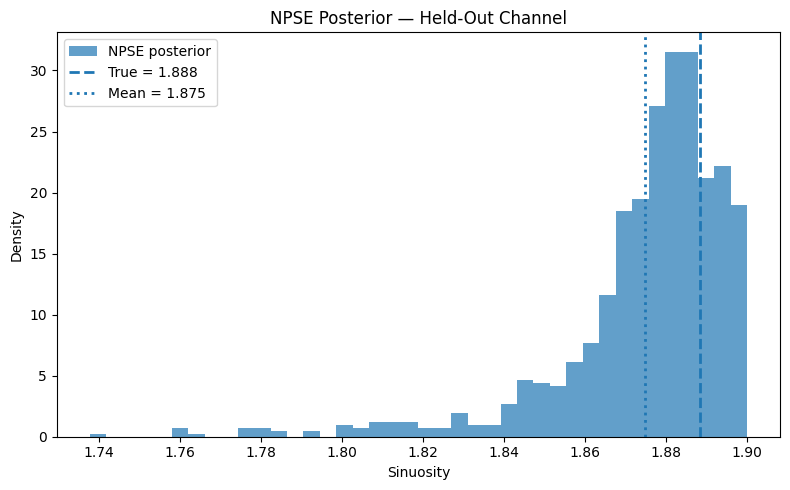

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(
    samples,
    bins=40,
    density=True,
    alpha=0.7,
    label="NPSE posterior"
)

plt.axvline(
    true_s,
    linestyle="--",
    linewidth=2,
    label=f"True = {true_s:.3f}"
)

plt.axvline(
    samples.mean(),
    linestyle=":",
    linewidth=2,
    label=f"Mean = {samples.mean():.3f}"
)

plt.xlabel("Sinuosity")
plt.ylabel("Density")
plt.title("NPSE Posterior — Held-Out Channel")
plt.legend()
plt.tight_layout()
plt.show()

# Two parts of evaluation: 1. Accuracy evluation - RMSE ; MAE 2. Uncertainty evaluation - 90% credible intervals

### 1. RMSE and MAE ON 200 Held out channel

MAE : 0.007381106
RMSE: 0.008935081


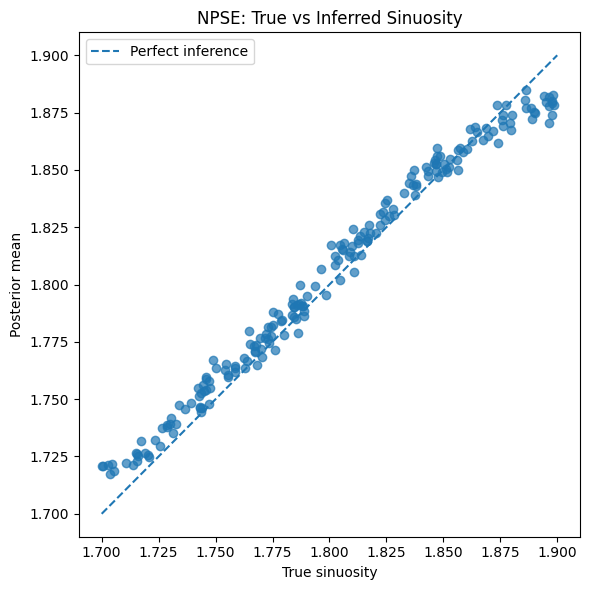

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = "output/npse"

# Load saved evaluation results
S_test = np.load(os.path.join(OUTPUT_DIR, "S_test.npy"))

posterior_means = np.load(os.path.join(OUTPUT_DIR, "posterior_means.npy"))

posterior_stds = np.load(os.path.join(OUTPUT_DIR, "posterior_stds.npy"))

# Calculate errors
errors = posterior_means - S_test

mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors ** 2))

print("MAE :", mae)
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(6, 6))

plt.scatter(S_test, posterior_means, alpha=0.7)

plt.plot(
    [1.7, 1.9],
    [1.7, 1.9],
    linestyle="--",
    label="Perfect inference"
)

plt.xlabel("True sinuosity")
plt.ylabel("Posterior mean")
plt.title("NPSE: True vs Inferred Sinuosity")
plt.legend()
plt.tight_layout()

# plt.savefig(
#     os.path.join(OUTPUT_DIR, "true_vs_inferred.png"),
#     dpi=300
# )

plt.show()

### 2.  90% credible intervals : 

In [7]:
# Load posterior samples
posterior_samples = np.load(os.path.join(OUTPUT_DIR, "eval_posterior_samples.npy"))
print("Posterior samples:", posterior_samples.shape)
# 90% credible interval = 5th to 95th percentile
lower = np.percentile(posterior_samples, 5, axis=1)
upper = np.percentile(posterior_samples, 95, axis=1)
# Check whether true sinuosity is inside the interval
inside = (S_test >= lower) & (S_test <= upper)
coverage = inside.mean()
print("90% credible interval coverage:", coverage)
print("Number inside:", inside.sum(), "/", len(S_test))

Posterior samples: (200, 200)
90% credible interval coverage: 0.965
Number inside: 193 / 200


Expected: 10% | Observed: 7.0%
Expected: 20% | Observed: 19.0%
Expected: 30% | Observed: 29.0%
Expected: 40% | Observed: 45.5%
Expected: 50% | Observed: 59.0%
Expected: 60% | Observed: 70.5%
Expected: 70% | Observed: 82.5%
Expected: 80% | Observed: 90.5%
Expected: 90% | Observed: 96.5%


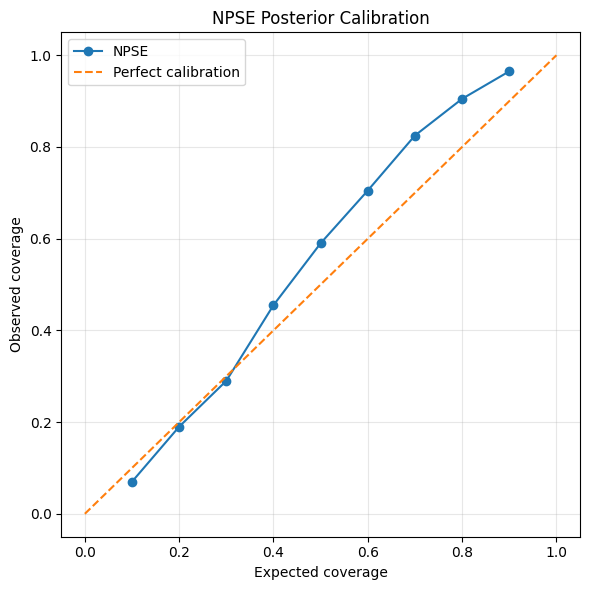

In [ ]:
# Credible interval levels to test
levels = np.arange(0.1, 1.0, 0.1)

observed_coverage = []

for level in levels:

    # e.g. 90% interval -> 5th and 95th percentiles
    alpha = (1 - level) / 2

    lower = np.quantile(
        posterior_samples,
        alpha,
        axis=1
    )

    upper = np.quantile(
        posterior_samples,
        1 - alpha,
        axis=1
    )

    inside = (S_test >= lower) & (S_test <= upper)

    observed_coverage.append(inside.mean())

# Print results
for expected, observed in zip(levels, observed_coverage):
    print(
        f"Expected: {expected:.0%} | "
        f"Observed: {observed:.1%}"
    )

plt.figure(figsize=(6, 6))

plt.plot(
    levels,
    observed_coverage,
    marker="o",
    label="NPSE"
)

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Expected coverage")
plt.ylabel("Observed coverage")
plt.title("NPSE Posterior Coverage")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# plt.savefig(
#     os.path.join(OUTPUT_DIR, "calibration_curve.png"),
#     dpi=300
# )

plt.show()